
---

# 📦 **Batch Normalization in Deep Learning**  
> *“Make deep networks train fast, smooth, and accurate.”* 🚀

---

## ✅ **What is Batch Normalization?**

📌 **Batch Normalization (BatchNorm)** is a technique to **normalize the inputs** of each layer so that they have **zero mean** and **unit variance** — **within each mini-batch**.

> Introduced by **Ioffe and Szegedy (2015)** in their paper "*Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*".

---

## 🤯 **Why Use Batch Normalization?**

During training, each layer’s input distribution keeps changing due to weight updates — this is called **internal covariate shift**.

### BatchNorm helps by:
✅ Stabilizing the input distribution to each layer  
✅ Smoothing the **loss landscape**  
✅ Enabling **higher learning rates**  
✅ Reducing need for other regularization (like dropout)  
✅ Often leads to **better generalization**

---

## 🔄 **How Does BatchNorm Work?**

For each mini-batch:

### Step 1: Compute Batch Statistics  
$
\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i \\
\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
$

### Step 2: Normalize the Input  
$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$

### Step 3: Scale and Shift  
$
y_i = \gamma \hat{x}_i + \beta
$

Where:  
- $ \gamma $ and $ \beta $ are **learnable parameters**  
- $ \epsilon $ is a small constant for numerical stability

---

## 📉 **Where Is It Applied?**

| Layer Type         | Apply BatchNorm After |
|--------------------|-----------------------|
| **Dense Layer**     | After the layer, before activation |
| **Conv Layer**      | After convolution, before activation |
| **ReLU / Leaky ReLU** | After BatchNorm |

### 👇 Example Flow:

```
[Input] → Dense → BatchNorm → ReLU → Output
```

---

## 🧪 **BatchNorm in Keras / TensorFlow**

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation

model = Sequential([
    Dense(128, input_shape=(784,)),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])
```

---

## ⚙️ **BatchNorm in PyTorch**

```python
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(784, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10),
    nn.Softmax(dim=1)
)
```

- Use `BatchNorm1d` for **fully connected layers**
- Use `BatchNorm2d` for **convolutional layers**

---

## 📈 **Advantages of Batch Normalization**

| ✅ Benefit                        | 💬 Description |
|----------------------------------|----------------|
| 🚀 Faster training               | Allows larger learning rates |
| 🧠 Reduced internal covariate shift | More stable feature distributions |
| ❌ Less dependence on initialization | Even bad initial weights can work |
| 🔄 Acts as a regularizer         | Sometimes replaces dropout |
| 📊 Improved generalization       | Often leads to higher accuracy |

---

## ⚠️ **Caveats & Considerations**

| ⚠️ Point                     | Explanation |
|-----------------------------|-------------|
| ❌ Don’t use tiny batch sizes | Estimating mean/variance becomes noisy |
| 🧪 Use **running averages** for inference | BatchNorm behaves differently during training & testing |
| 🤖 BatchNorm in RNNs tricky | Prefer LayerNorm or other techniques for sequence models |

---

## 🧠 Inference vs Training Mode

### 🔹 During Training:
- Uses **batch mean and variance**  
- Learns $ \gamma $, $ \beta $

### 🔹 During Inference:
- Uses **running (moving) averages** computed during training  
- Ensures consistency across batches

---

## 🔚 Summary

| 🧩 Feature       | ✅ Value |
|------------------|---------|
| Type             | Normalization Layer |
| Use Case         | Deep networks, CNNs, MLPs |
| Key Benefit      | Faster convergence, better generalization |
| Alternatives     | LayerNorm, GroupNorm, InstanceNorm |
| Works Best With  | ReLU, large batch sizes |

---

## 🧠 TL;DR

> **Batch Normalization** is a game-changer in deep learning — it lets your model **learn faster, train deeper, and generalize better**.


---

### **Implementation**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/Adityarajora/Complete-KNN-visualization/refs/heads/master/3.concertriccir2.csv')

In [6]:
# Set the column names
df.columns = ['X', 'Y', 'class']

# Create a new DataFrame for the column names
header = pd.DataFrame(columns=['X', 'Y', 'class'])

# Concatenate the header and the original DataFrame
df = pd.concat([header, df], ignore_index=True)

In [7]:
df.head()

,X,Y,class
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


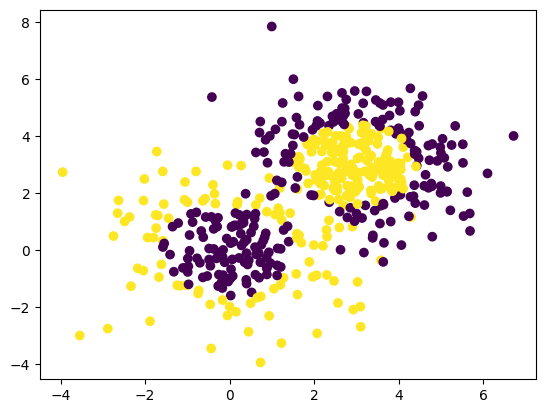

In [8]:
plt.scatter(df['X'],df['Y'],c=df['class'])
plt.show()

In [9]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

### **Without Batch Normalization**

In [11]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3968 - loss: 0.6911 - val_accuracy: 0.4300 - val_loss: 0.7095
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4482 - loss: 0.6826 - val_accuracy: 0.4300 - val_loss: 0.7092
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4303 - loss: 0.6865 - val_accuracy: 0.4200 - val_loss: 0.7084
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4252 - loss: 0.6894 - val_accuracy: 0.4100 - val_loss: 0.7077
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3897 - loss: 0.6841 - val_accuracy: 0.4100 - val_loss: 0.7076
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4332 - loss: 0.6831 - val_accuracy: 0.4100 - val_loss: 0.7071
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4164 - loss: 0.6808 - val_accuracy: 0.4100 - val_loss: 0.7062
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3990 - loss: 0.6872 - val_accuracy: 0.

### **With Batch Normalization**

In [14]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [15]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6043 - loss: 0.6593 - val_accuracy: 0.4100 - val_loss: 0.7112
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6225 - loss: 0.6479 - val_accuracy: 0.4100 - val_loss: 0.7070
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6278 - loss: 0.6529 - val_accuracy: 0.4300 - val_loss: 0.7035
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6124 - loss: 0.6583 - val_accuracy: 0.4800 - val_loss: 0.7000
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6032 - loss: 0.6658 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6122 - loss: 0.6467 - val_accuracy: 0.5300 - val_loss: 0.6912
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6075 - loss: 0.6586 - val_accuracy: 0.5300 - val_loss: 0.6874
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5916 - loss: 0.6577 - val_accuracy: 0.5500

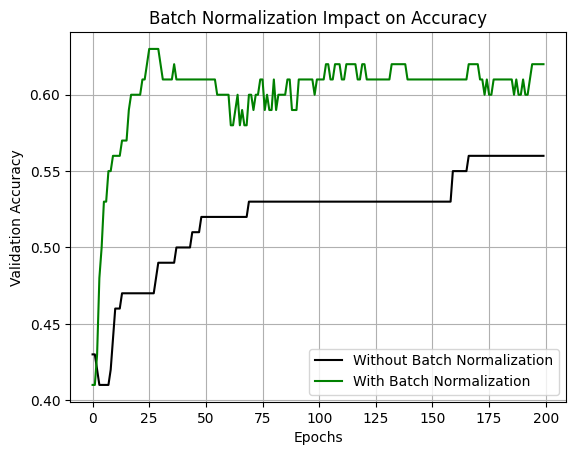

In [18]:
# Plotting the validation accuracy
plt.plot(history1.history['val_accuracy'], color='black', label='Without Batch Normalization')
plt.plot(history2.history['val_accuracy'], color='green', label='With Batch Normalization')

# Adding titles and labels
plt.title('Batch Normalization Impact on Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')

# Adding a legend to distinguish the lines
plt.legend()

# Adding grid for better readability
plt.grid(True)

# Show the plot
plt.show()

---